# 활성 시청자 비율 — 팬덤 위험도 구성 요소

## 전체 위험도 프레임워크에서의 위치
```
최종 위험도 (ABCDF)
├── 평판 위험도 33%
├── 트래픽 위험도 33%
└── 팬덤 위험도 33%  ← [활성 시청자 비율 ← 현재] + 시청 유지 안정성
```

## 설계 원칙
> 구독자 수는 많아도 실제로 영상을 보는 사람이 적으면 팬덤이 약한 채널입니다.
> **구독자 대비 평균 조회수 비율(view_per_sub)** 을 중심으로 채널을 군집화하고,
> 군집 위치에 따라 팬덤 건강도를 0~1 점수로 출력합니다.

## 출력
- `active_viewer_score`: 0~1, 높을수록 활성 시청자 비율이 건강함
- `fandom_cluster`: 군집 번호 + 군집명 (슈퍼팬 / 일반 / 이탈 위험 / 유령 구독자)


## 0. 라이브러리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing  import StandardScaler
from sklearn.cluster        import KMeans
from sklearn.metrics        import silhouette_score

RANDOM_STATE = 42
print("라이브러리 로드 완료")


라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
wide = pd.read_csv("../../data/raw/filtered_dataset_wide.csv")
print(f"wide shape: {wide.shape}")
wide[["title","subscriber_count","avg_view_count","avg_like_count","avg_comment_count"]].head(5)


wide shape: (3336, 22)


,title,subscriber_count,avg_view_count,avg_like_count,avg_comment_count
0,2M (투엠) ENT,100000,3583.14,84.52,2.96
1,심킹 (ABYSSKIMG),100000,55364.56,483.32,176.76
2,김PD전당포,100000,1516.14,34.86,2.16
3,DC튜브,100000,5020.40,62.90,21.66
4,두리 원투쓰리코,109000,20873.78,88.86,6.80


## 2. 활성 시청자 관련 피처 생성

| 피처 | 계산식 | 의미 |
|---|---|---|
| `view_per_sub` | 평균 조회수 / 구독자 수 | 구독자 중 실제로 영상을 보는 비율 |
| `like_per_view` | 평균 좋아요 / 평균 조회수 | 본 사람 중 반응하는 비율 |
| `comment_per_view` | 평균 댓글 / 평균 조회수 | 본 사람 중 적극적으로 참여하는 비율 |
| `log_view_per_sub` | log(1 + view_per_sub) | 극단값 완화용 변환값 (군집화 입력) |

> `view_per_sub` 해석 기준
> - 1.0 이상 → 구독자보다 조회수가 많음 (알고리즘 유입 강함)
> - 0.1 ~ 1.0 → 건강한 일반 채널 수준
> - 0.1 미만 → 구독자 대비 조회수 낮음 (유령 구독자 비율 높을 가능성)


In [3]:
wide["view_per_sub"]     = wide["avg_view_count"]    / (wide["subscriber_count"] + 1e-9)
wide["like_per_view"]    = wide["avg_like_count"]    / (wide["avg_view_count"]   + 1e-9)
wide["comment_per_view"] = wide["avg_comment_count"] / (wide["avg_view_count"]   + 1e-9)
wide["log_view_per_sub"] = np.log1p(wide["view_per_sub"])

print("=== 피처 분포 ===")
print(wide[["view_per_sub","like_per_view","comment_per_view"]].describe().round(4))


=== 피처 분포 ===
       view_per_sub  like_per_view  comment_per_view
count     3336.0000      3270.0000         3314.0000
mean         0.6738         0.0189            0.0015
std          4.0601         0.0183            0.0020
min          0.0000         0.0000            0.0000
25%          0.0857         0.0093            0.0005
50%          0.2462         0.0139            0.0010
75%          0.6233         0.0219            0.0019
max        220.2154         0.2314            0.0637


## 3. 최적 군집 수(K) 탐색 — Elbow + Silhouette

두 지표를 함께 봐서 K를 결정합니다.
- Elbow: inertia가 급격히 꺾이는 지점
- Silhouette: 높을수록 군집이 잘 나뉘어짐


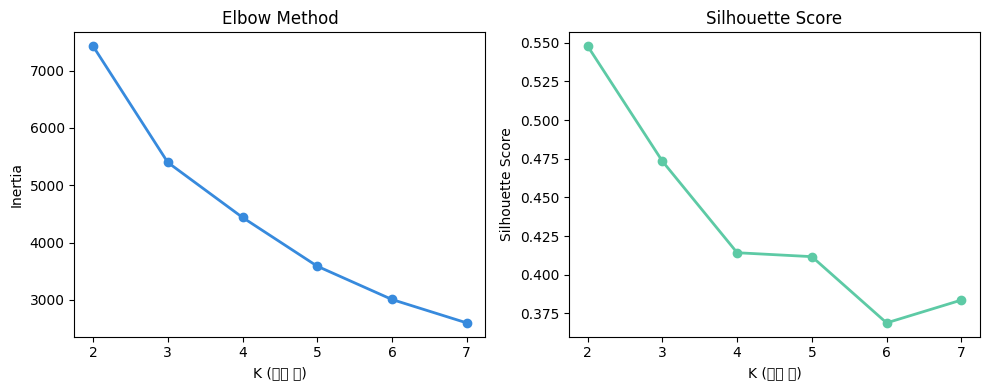

K별 Silhouette Score:
  k=2: 0.5477
  k=3: 0.4733
  k=4: 0.4142
  k=5: 0.4117
  k=6: 0.3689
  k=7: 0.3836


In [4]:
FEATURE_COLS = ["log_view_per_sub", "like_per_view", "comment_per_view"]

X = wide[FEATURE_COLS].fillna(0)
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, silhouettes = [], []
K_range = range(2, 8)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(list(K_range), inertias, "o-", color="#378ADD", lw=2)
axes[0].set_xlabel("K (군집 수)"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), silhouettes, "o-", color="#5DCAA5", lw=2)
axes[1].set_xlabel("K (군집 수)"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")

plt.tight_layout()
plt.show()

print("K별 Silhouette Score:")
for k, s in zip(K_range, silhouettes):
    print(f"  k={k}: {s:.4f}")


## 4. K-Means 군집화 (K=4)

4개 군집은 아래 팬덤 유형에 대응합니다.

| 군집 | 팬덤 유형 | 특징 |
|---|---|---|
| 슈퍼팬 | view_per_sub 높음 + 참여율 높음 | 구독자 대부분이 실제 시청, 적극 반응 |
| 일반 팬 | view_per_sub 보통 + 참여율 보통 | 건강한 일반 채널 수준 |
| 소극적 팬 | view_per_sub 보통 + 참여율 낮음 | 보긴 보지만 반응 안 함 |
| 유령 구독자 | view_per_sub 낮음 | 구독만 하고 안 봄 → 팬덤 위험 |


In [5]:
K_BEST = 4   # Elbow + Silhouette 기반 선택, 필요 시 수정

km_final = KMeans(n_clusters=K_BEST, random_state=RANDOM_STATE, n_init=10)
wide["cluster"] = km_final.fit_predict(X_scaled)

# 군집별 평균값으로 군집 성격 파악
cluster_summary = wide.groupby("cluster")[
    ["view_per_sub","like_per_view","comment_per_view","subscriber_count"]
].mean().round(4)

print("=== 군집별 평균 피처 ===")
print(cluster_summary)
print()
print("=== 군집별 채널 수 ===")
print(wide["cluster"].value_counts().sort_index())


=== 군집별 평균 피처 ===
         view_per_sub  like_per_view  comment_per_view  subscriber_count
cluster                                                                 
0              0.2799         0.0126            0.0010       374084.7857
1              2.9934         0.0135            0.0008       307479.5082
2              0.2245         0.1033            0.0078       389000.0000
3              0.2705         0.0339            0.0030       332317.0992

=== 군집별 채널 수 ===
cluster
0    2123
1     488
2      70
3     655
Name: count, dtype: int64


In [6]:
# 군집 번호 → 이름 매핑
# view_per_sub 평균 기준으로 자동 정렬해서 이름 부여
cluster_vps = cluster_summary["view_per_sub"].sort_values(ascending=False)

rank_to_name = {
    0: "슈퍼팬 (최고 활성)",
    1: "일반 팬 (건강)",
    2: "소극적 팬 (참여 저조)",
    3: "유령 구독자 (위험)",
}

cluster_name_map = {}
for rank, (cluster_id, _) in enumerate(cluster_vps.items()):
    cluster_name_map[cluster_id] = rank_to_name[rank]

wide["cluster_name"] = wide["cluster"].map(cluster_name_map)

print("=== 군집 이름 매핑 ===")
for cid, name in sorted(cluster_name_map.items()):
    n = (wide["cluster"] == cid).sum()
    vps = cluster_summary.loc[cid, "view_per_sub"]
    print(f"  군집 {cid}: {name:20s} | 채널 {n}개 | view_per_sub={vps:.4f}")


=== 군집 이름 매핑 ===
  군집 0: 일반 팬 (건강)            | 채널 2123개 | view_per_sub=0.2799
  군집 1: 슈퍼팬 (최고 활성)          | 채널 488개 | view_per_sub=2.9934
  군집 2: 유령 구독자 (위험)          | 채널 70개 | view_per_sub=0.2245
  군집 3: 소극적 팬 (참여 저조)        | 채널 655개 | view_per_sub=0.2705


## 5. 활성 시청자 점수 계산 (0~1)

군집 기반 기본 점수 + view_per_sub · 참여율 보정으로 연속적인 점수를 산출합니다.

```
base_score     = 군집별 기준값 (슈퍼팬=0.85, 일반=0.60, 소극=0.35, 유령=0.15)
bonus          = clip(log_view_per_sub / max_log_vps, 0, 1) × 0.10
engagement_adj = clip(like_per_view + comment_per_view, 0, 0.2) × 0.25

active_viewer_score = clip(base_score + bonus + engagement_adj, 0, 1)
```


In [7]:
# 군집 기준 점수 (view_per_sub 내림차순 군집 순서 기준)
BASE_SCORE_MAP = {
    "슈퍼팬 (최고 활성)"   : 0.85,
    "일반 팬 (건강)"        : 0.60,
    "소극적 팬 (참여 저조)" : 0.35,
    "유령 구독자 (위험)"    : 0.15,
}

max_log_vps = wide["log_view_per_sub"].max()

def calc_active_score(row):
    base       = BASE_SCORE_MAP.get(row["cluster_name"], 0.5)

    # log_view_per_sub 보정: 같은 군집 내에서도 비율이 높을수록 소폭 가산
    bonus      = np.clip(row["log_view_per_sub"] / (max_log_vps + 1e-9), 0, 1) * 0.10

    # 참여율 보정: 좋아요 + 댓글 반응이 클수록 소폭 가산
    eng        = row["like_per_view"] + row["comment_per_view"]
    eng_adj    = np.clip(eng, 0, 0.2) / 0.2 * 0.05

    score = base + bonus + eng_adj
    return round(float(np.clip(score, 0, 1)), 4)

wide["active_viewer_score"] = wide.apply(calc_active_score, axis=1)

print("=== active_viewer_score 분포 ===")
print(wide["active_viewer_score"].describe().round(4))


=== active_viewer_score 분포 ===
count    3251.0000
mean        0.5893
std         0.1617
min         0.1653
25%         0.6022
50%         0.6065
75%         0.6119
max         0.9518
Name: active_viewer_score, dtype: float64


## 6. 결과 확인

In [8]:
result = wide[[
    "channel_id","title",
    "subscriber_count","avg_view_count",
    "view_per_sub","like_per_view","comment_per_view",
    "cluster","cluster_name","active_viewer_score",
]].sort_values("active_viewer_score", ascending=False).reset_index(drop=True)

print("=== 활성 시청자 점수 (높은 순) ===")
print(result[[
    "title","cluster_name","view_per_sub","active_viewer_score"
]].to_string(index=False))


=== 활성 시청자 점수 (높은 순) ===
                                    title  cluster_name  view_per_sub  active_viewer_score
                              RosaliaVEVO   슈퍼팬 (최고 활성)    220.215356               0.9518
                          TheKidLAROIVEVO   슈퍼팬 (최고 활성)     46.433999               0.9265
                                  timeory   슈퍼팬 (최고 활성)     20.297805               0.9117
                                HITEJINRO   슈퍼팬 (최고 활성)     18.429046               0.9051
                          겨울아빠 WinterPapa   슈퍼팬 (최고 활성)     15.462956               0.9028
                                 유니버설 픽쳐스   슈퍼팬 (최고 활성)     14.373415               0.9008
                               넥슨 YouTube   슈퍼팬 (최고 활성)     13.534875               0.8996
                                   짧은내복야코   슈퍼팬 (최고 활성)      9.760790               0.8996
                     플레이유 레벨업 : 빌런이 사는 세상   슈퍼팬 (최고 활성)     10.943378               0.8991
                                ArtSoccer   슈퍼팬 (최고 활성)     11.17

## 7. 시각화

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

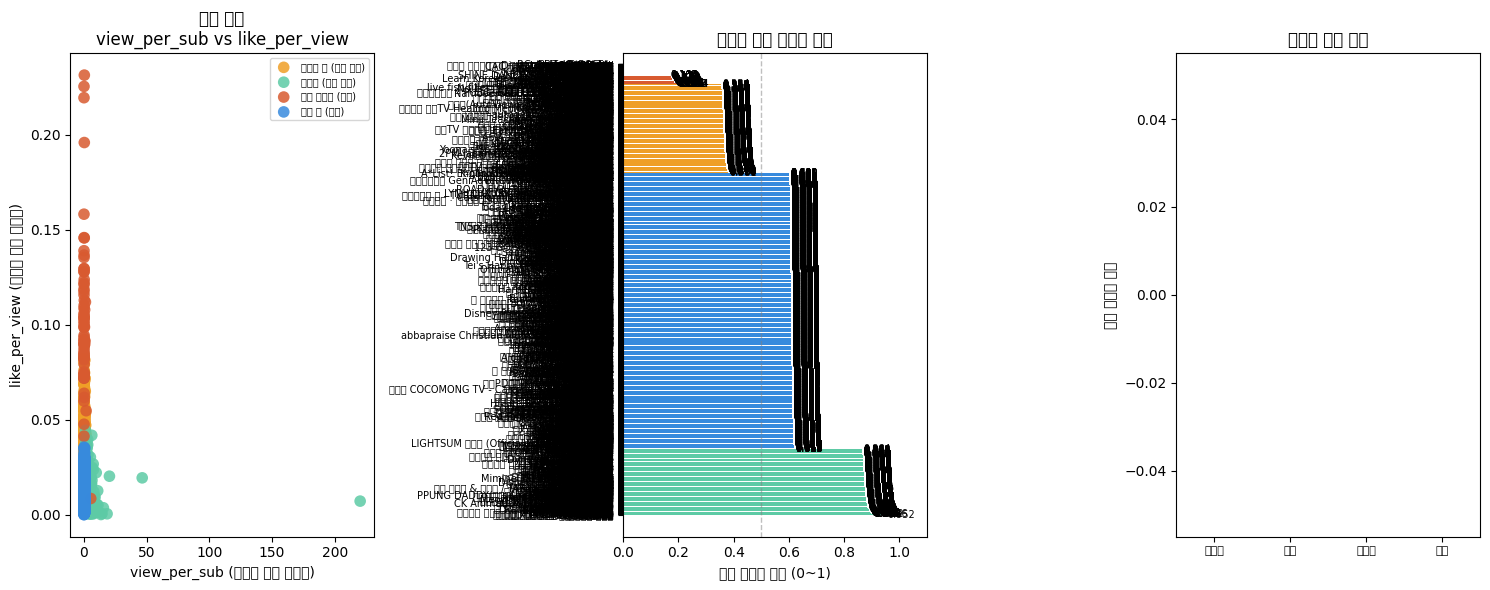

In [9]:
CLUSTER_COLORS = {
    "슈퍼팬 (최고 활성)"   : "#5DCAA5",
    "일반 팬 (건강)"        : "#378ADD",
    "소극적 팬 (참여 저조)" : "#EF9F27",
    "유령 구독자 (위험)"    : "#D85A30",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# ── ① 산점도: view_per_sub vs like_per_view ──────────────────────────────────
for name, grp in wide.groupby("cluster_name"):
    axes[0].scatter(
        grp["view_per_sub"], grp["like_per_view"],
        c=CLUSTER_COLORS.get(name, "#888"),
        label=name, s=70, alpha=0.85, edgecolors="none"
    )
axes[0].set_xlabel("view_per_sub (구독자 대비 조회수)")
axes[0].set_ylabel("like_per_view (조회수 대비 좋아요)")
axes[0].set_title("군집 분포\nview_per_sub vs like_per_view")
axes[0].legend(fontsize=7, loc="upper right")

# ── ② 채널별 active_viewer_score 바차트 ─────────────────────────────────────
colors_bar = [CLUSTER_COLORS.get(n, "#888") for n in result["cluster_name"]]
axes[1].barh(result["title"], result["active_viewer_score"],
             color=colors_bar, edgecolor="none")
for i, v in enumerate(result["active_viewer_score"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=7)
axes[1].axvline(0.5, color="gray", linestyle="--", lw=1, alpha=0.5)
axes[1].set_xlabel("활성 시청자 점수 (0~1)")
axes[1].set_title("채널별 활성 시청자 점수")
axes[1].set_xlim(0, 1.1)
axes[1].tick_params(axis="y", labelsize=7)

# ── ③ 군집별 점수 분포 박스플롯 ──────────────────────────────────────────────
order = list(BASE_SCORE_MAP.keys())
data_by_cluster = [
    wide[wide["cluster_name"] == name]["active_viewer_score"].tolist()
    for name in order
]
bp = axes[2].boxplot(data_by_cluster, patch_artist=True, widths=0.5)
for patch, name in zip(bp["boxes"], order):
    patch.set_facecolor(CLUSTER_COLORS.get(name, "#888"))
    patch.set_alpha(0.7)
axes[2].set_xticklabels([n.split(" ")[0] for n in order], fontsize=8)
axes[2].set_ylabel("활성 시청자 점수")
axes[2].set_title("군집별 점수 분포")

plt.tight_layout()
plt.show()


In [10]:
# 군집별 채널 수 + 평균 점수 요약
print("=== 군집별 요약 ===")
summary = wide.groupby("cluster_name").agg(
    채널수       = ("channel_id", "count"),
    평균점수     = ("active_viewer_score", "mean"),
    평균view_per_sub = ("view_per_sub", "mean"),
    평균like_per_view = ("like_per_view", "mean"),
).round(4)
print(summary.to_string())


=== 군집별 요약 ===
                채널수    평균점수  평균view_per_sub  평균like_per_view
cluster_name                                                
소극적 팬 (참여 저조)   655  0.3633          0.2705           0.0339
슈퍼팬 (최고 활성)     488  0.8747          2.9934           0.0135
유령 구독자 (위험)      70  0.1798          0.2245           0.1033
일반 팬 (건강)      2123  0.6077          0.2799           0.0126


## 8. 저장

In [11]:
output = result[[
    "channel_id","title",
    "subscriber_count","avg_view_count","view_per_sub",
    "cluster","cluster_name","active_viewer_score",
]].copy()

output.to_csv("../../data/raw/active_viewer_score.csv", index=False, encoding="utf-8-sig")
print("저장 완료: active_viewer_score.csv")
print()
print("=== 최종 출력 샘플 ===")
print(output[["title","cluster_name","active_viewer_score"]].to_string(index=False))


저장 완료: active_viewer_score.csv

=== 최종 출력 샘플 ===
                                    title  cluster_name  active_viewer_score
                              RosaliaVEVO   슈퍼팬 (최고 활성)               0.9518
                          TheKidLAROIVEVO   슈퍼팬 (최고 활성)               0.9265
                                  timeory   슈퍼팬 (최고 활성)               0.9117
                                HITEJINRO   슈퍼팬 (최고 활성)               0.9051
                          겨울아빠 WinterPapa   슈퍼팬 (최고 활성)               0.9028
                                 유니버설 픽쳐스   슈퍼팬 (최고 활성)               0.9008
                               넥슨 YouTube   슈퍼팬 (최고 활성)               0.8996
                                   짧은내복야코   슈퍼팬 (최고 활성)               0.8996
                     플레이유 레벨업 : 빌런이 사는 세상   슈퍼팬 (최고 활성)               0.8991
                                ArtSoccer   슈퍼팬 (최고 활성)               0.8976
                 룰루랄라 뮤직 - LuluLala Music   슈퍼팬 (최고 활성)               0.8974
                    잡코리아x알바

## 점수 해석 & 팬덤 위험도 통합 가이드

### 점수 구간별 의미
| 점수 | 등급 | 의미 |
|---|---|---|
| 0.75 ~ 1.00 | 슈퍼팬 | 구독자 대부분이 실제 시청, 팬덤 매우 건강 |
| 0.50 ~ 0.75 | 일반 | 건강한 일반 채널 수준 |
| 0.30 ~ 0.50 | 소극적 | 시청은 하지만 반응 저조, 관리 필요 |
| 0.00 ~ 0.30 | 위험 | 유령 구독자 비율 높음, 팬덤 이탈 위험 |

### 팬덤 위험도 통합 시
이 점수는 **높을수록 건강**하므로, 위험도 합산 시 반전이 필요합니다.

```python
fandom_risk = 1 - active_viewer_score   # 위험도로 변환

fandom_danger = (
    fandom_risk              * 0.5 +   # 활성 시청자 비율
    watch_stability_risk     * 0.5     # 시청 유지 안정성 (미구현)
)
```
